# Analyze Phase
- [x] Aggregate your data so it’s useful and accessible.
- [x] Organize and format your data.
- [x] Perform calculations.
- [x] Identify trends and relationships.

In [3]:
# Installing and loading common libraries
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Load your CSV files
df_daily = pd.read_csv('../data/daily_activity_data_analyze.csv')

# 1. Aggregate your data so it’s useful and accessible.
# 2. Organize and format your data.

In [4]:
# stain the weekday order
week_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
df_daily['WeekDay'] = pd.Categorical(df_daily['WeekDay'], categories=week_order, ordered=True)

In [7]:
# total by weekday
sum_by_weekday = df_daily[['TotalSteps','CalculatedTotalDistance','Calories','WeekDay']].groupby('WeekDay',observed=False).sum()
sum_by_weekday = sum_by_weekday.rename(columns={'TotalSteps': 'Total Steps', 'CalculatedTotalDistance': 'Total Distance', 'Calories': 'Total Calories'})
print(sum_by_weekday) # Debugging only

           Total Steps  Total Distance  Total Calories
WeekDay                                               
Monday       1417768.0         1044.06        432100.0
Tuesday      1462256.0         1075.13        449271.0
Wednesday    1494420.0         1108.64        459511.0
Thursday     1417318.0         1036.20        433632.0
Friday       1430319.0         1049.89        462694.0
Saturday     1542702.0         1102.55        462835.0
Sunday       1275098.0          919.53        429890.0


In [8]:
# mean by weekday
mean_by_weekday = df_daily[['TotalSteps','CalculatedTotalDistance','Calories','WeekDay']].groupby('WeekDay', observed=False).mean()
mean_by_weekday = mean_by_weekday.rename(columns={'TotalSteps': 'Mean Steps', 'CalculatedTotalDistance': 'Mean Distance', 'Calories': 'Mean Calories'})
print(mean_by_weekday) # Debugging only

            Mean Steps  Mean Distance  Mean Calories
WeekDay                                             
Monday     7541.319149       5.553511    2298.404255
Tuesday    7274.905473       5.348905    2235.179104
Wednesday  7547.575758       5.599192    2320.762626
Thursday   7268.297436       5.313846    2223.753846
Friday     7187.532663       5.275829    2325.095477
Saturday   7752.271357       5.540452    2325.804020
Sunday     6606.725389       4.764404    2227.409326


In [9]:
def classyfy_day(day):
  if day in ['Saturday','Sunday']:
    return 'Weekend'
  else:
    return 'Weekday'

df_daily['Daytype'] = df_daily['WeekDay'].apply(classyfy_day)

In [10]:
# mean by weekday vs weekend
mean_by_daytype = df_daily.groupby(['Daytype'], observed=False)[['TotalSteps','CalculatedTotalDistance','Calories']].mean()
mean_by_daytype = mean_by_daytype.rename(columns={'CalculatedTotalDistance': 'TotalDistance'})
print(mean_by_daytype) # Debugging only

          TotalSteps  TotalDistance     Calories
Daytype                                         
Weekday  7361.958206       5.416840  2280.538226
Weekend  7188.265306       5.158367  2277.359694


In [11]:
# # of rows by daytype
count_by_daytype = df_daily.groupby(['Daytype'], observed=False).size().reset_index()
count_by_daytype.columns = ['Daytype', 'Number of Date']
print(count_by_daytype) # Debugging only

   Daytype  Number of Date
0  Weekday             981
1  Weekend             392


In [12]:
# add Week column
df_daily['ActivityDate'] = pd.to_datetime(df_daily['ActivityDate'])
df_daily['Week'] = df_daily['ActivityDate'].dt.isocalendar().week
df_daily['Month'] = df_daily['ActivityDate'].dt.month

In [14]:
# total by week, month
sum_by_week = df_daily.groupby('Week', observed=False)[['TotalSteps','CalculatedTotalDistance','Calories']].sum()
sum_by_week = sum_by_week.rename(columns={'TotalSteps': 'Total Steps', 'CalculatedTotalDistance': 'Total Distance', 'Calories': 'Total Calories'})
print(sum_by_week) # Debugging only

sum_by_month = df_daily.groupby('Month', observed=False)[['TotalSteps','CalculatedTotalDistance','Calories']].sum()
sum_by_month = sum_by_month.rename(columns={'TotalSteps': 'Total Steps', 'CalculatedTotalDistance': 'Total Distance', 'Calories': 'Total Calories'})
print(sum_by_month) # Debugging only

      Total Steps  Total Distance  Total Calories
Week                                             
10         8769.0            6.28          9024.0
11        58317.0           42.07         35223.0
12       104478.0           72.59         46271.0
13       892757.0          640.79        319606.0
14      1698345.0         1255.91        520690.0
15      1593937.0         1158.62        491525.0
16      1777299.0         1309.55        528826.0
17      1705934.0         1240.52        511645.0
18      1516993.0         1108.61        469610.0
19       683052.0          501.06        197513.0
       Total Steps  Total Distance  Total Calories
Month                                             
3         370092.0          257.93        168623.0
4        7262874.0         5319.15       2227274.0
5        2406915.0         1758.92        734036.0


In [15]:
# mean by week, month
mean_by_week = df_daily.groupby('Week', observed=False)[['TotalSteps','CalculatedTotalDistance','Calories']].mean()
mean_by_week = mean_by_week.rename(columns={'TotalSteps': 'Mean Steps', 'CalculatedTotalDistance': 'Mean Distance', 'Calories': 'Mean Calories'})
print(mean_by_week) # Debugging only

mean_by_month = df_daily.groupby('Month', observed=False)[['TotalSteps','CalculatedTotalDistance','Calories']].mean()
mean_by_month = mean_by_month.rename(columns={'TotalSteps': 'Mean Steps', 'CalculatedTotalDistance': 'Mean Distance', 'Calories': 'Mean Calories'})
print(mean_by_month) # Debugging only

       Mean Steps  Mean Distance  Mean Calories
Week                                           
10    2192.250000       1.570000    2256.000000
11    4165.500000       3.005000    2515.928571
12    5223.900000       3.629500    2313.550000
13    6376.835714       4.577071    2282.900000
14    7384.108696       5.460478    2263.869565
15    7212.384615       5.242624    2224.095023
16    7934.370536       5.846205    2360.830357
17    7719.158371       5.613213    2315.135747
18    7547.228856       5.515473    2336.368159
19    6969.918367       5.112857    2015.438776
        Mean Steps  Mean Distance  Mean Calories
Month                                           
3      5001.243243       3.485541    2278.689189
4      7487.498969       5.483660    2296.158763
5      7315.851064       5.346261    2231.112462


In [16]:
# # of rows by week, month
count_by_week = df_daily.groupby(['Week'], observed=False).size()
count_by_week.columns = ['Week Number', 'Number of Date in a Week']
count_by_month = df_daily.groupby(['Month'], observed=False).size()
count_by_month.columns = ['Month', 'Number of Date in a Month']
print(count_by_week) # Debugging only
print(count_by_month)

Week
10      4
11     14
12     20
13    140
14    230
15    221
16    224
17    221
18    201
19     98
dtype: int64
Month
3     74
4    970
5    329
dtype: int64


# 3. Perform calculations.

In [17]:
## total, mean, max min, rate of activity_day by Id
column_without_date = [
  'TotalSteps', 'TrackerDistance', 'LoggedActivitiesDistance', 'VeryActiveDistance', 'ModeratelyActiveDistance', 'LightActiveDistance', 'SedentaryActiveDistance', 'VeryActiveMinutes', 'FairlyActiveMinutes', 'LightlyActiveMinutes', 'SedentaryMinutes', 'Calories', 'CalculatedTotalDistance'
  ]
sum_by_id = df_daily.groupby(['Id'], observed=False)[column_without_date].sum()
mean_by_id = df_daily.groupby(['Id'], observed=False)[column_without_date].mean()
max_by_id = df_daily.groupby(['Id'], observed=False)[column_without_date].max()
min_by_id = df_daily.groupby(['Id'], observed=False)[column_without_date].min()


activdate_by_id = df_daily.groupby(['Id'], observed=False)[['ActivityDate']].size()
date_start = pd.to_datetime('2016-03-12')
date_end = pd.to_datetime('2016-05-12')
diff_date = (date_end-date_start).days + 1
rate_activdate_by_id = (activdate_by_id / diff_date) * 100

In [18]:
print(sum_by_id) # Debugging only
print(mean_by_id)
print(max_by_id)
print(min_by_id)
print(activdate_by_id)
print(rate_activdate_by_id)

            TotalSteps  TrackerDistance  LoggedActivitiesDistance  \
Id                                                                  
1503960366    590096.0       382.320000                  0.000000   
1624580081    250965.0       168.740000                  0.000000   
1644430081    311237.0       226.350001                  0.000000   
1844505072    120320.5        79.555000                  0.000000   
1927972279     54219.0        37.555000                  0.000000   
2022484408    489293.0       349.369999                  0.000000   
2026352035    210569.5       130.655000                  0.000000   
2320127002    177472.5       119.839999                  0.000000   
2347167796    313298.5       208.655000                  0.000000   
2873212765    309470.0       208.824999                  0.000000   
2891001357      6189.0         0.000000                  9.656064   
3372868164    198508.0       136.300001                  0.000000   
3977333714    428696.5       291.9

In [19]:
# average of VeryActiveMinutes, FairlyActiveMinutes, LightlyActiveMinutes
variety_of_active = df_daily[['VeryActiveMinutes','FairlyActiveMinutes','LightlyActiveMinutes']].mean()
variety_of_active = variety_of_active.rename(index={'VeryActiveMinutes': 'Average Very Active Minutes', 'FairlyActiveMinutes': 'Average Fairly Active Minutes','LightlyActiveMinutes': 'Average Lightly Active Minutes'})
print(variety_of_active) # Debugging only

Average Very Active Minutes        19.711216
Average Fairly Active Minutes      13.553168
Average Lightly Active Minutes    186.353241
dtype: float64


In [20]:
## rate of VeryActiveMinutes, FairlyActiveMinutes, LightlyActiveMinutes, SedentaryMinutes
total_of_VeryActiveMinutes = df_daily['VeryActiveMinutes'].sum()
total_of_FairlyActiveMinutes = df_daily['FairlyActiveMinutes'].sum()
total_of_LightlyActiveMinutes = df_daily['LightlyActiveMinutes'].sum()
total_of_SedentaryMinutes = df_daily['SedentaryMinutes'].sum()
total_activity_min = total_of_VeryActiveMinutes + total_of_FairlyActiveMinutes + total_of_LightlyActiveMinutes + total_of_SedentaryMinutes
rate_very = (total_of_VeryActiveMinutes/total_activity_min)*100
rate_fairly = (total_of_FairlyActiveMinutes/total_activity_min)*100
rate_lightly = (total_of_LightlyActiveMinutes/total_activity_min)*100
rate_sedentary = (total_of_SedentaryMinutes/total_activity_min)*100
total_rate_activity = rate_very + rate_fairly + rate_lightly + rate_sedentary
rate_activity_min = {'Rate': [rate_very, rate_fairly, rate_lightly, rate_sedentary, total_rate_activity]}
df_rate_activity_min= pd.DataFrame(data=rate_activity_min, index=['Very Active','Failrly Activity','Lightly Activity','Sedentary Activity','Total'])
print(df_rate_activity_min) # Debugging only

                          Rate
Very Active           1.619651
Failrly Activity      1.113650
Lightly Activity     15.312459
Sedentary Activity   81.954240
Total               100.000000


In [21]:
# average calories by date
total_calories_by_date = df_daily.groupby('ActivityDate', observed=False)['Calories'].mean().reset_index()
total_calories_by_date.columns = ['Activity Date', 'Average Calories']
print(total_calories_by_date) # Debugging only

   Activity Date  Average Calories
0     2016-03-12       2383.500000
1     2016-03-13       2128.500000
2     2016-03-14       2511.500000
3     2016-03-15       2396.000000
4     2016-03-16       2882.500000
..           ...               ...
57    2016-05-08       2303.444444
58    2016-05-09       2335.666667
59    2016-05-10       2229.346154
60    2016-05-11       2190.083333
61    2016-05-12       1139.285714

[62 rows x 2 columns]


In [24]:
# rate active date
total_date = ((dt.date(2016,5,12) - dt.date(2016,3,12)).days + 1) * 35 #35 unique users
total_active_date = df_daily['ActivityDate'].count()
rate_active_date = (total_active_date / total_date) * 100
rate_none_active_date = ((total_date-total_active_date)/total_date)*100
data_active_date = {'Rate': [rate_active_date,rate_none_active_date,rate_active_date+rate_none_active_date]}
df_rate_active_date = pd.DataFrame(data=data_active_date, index=['Active Date','Non Active Date','Total'])
print(df_rate_active_date) # Debugging only
sum_active_min_weekday = df_daily.groupby(['WeekDay'], observed=False)[['VeryActiveMinutes','FairlyActiveMinutes','LightlyActiveMinutes','SedentaryMinutes']].sum()
print(sum_active_min_weekday) # Debugging only
mean_active_min_weekday = df_daily.groupby(['WeekDay'], observed=False)[['VeryActiveMinutes','FairlyActiveMinutes','LightlyActiveMinutes','SedentaryMinutes']].mean()
print(mean_active_min_weekday) # Debugging only
sum_active_min_month = df_daily.groupby(['Month'], observed=False)[['VeryActiveMinutes','FairlyActiveMinutes','LightlyActiveMinutes','SedentaryMinutes']].sum()
print(sum_active_min_month) # Debugging only
mean_active_min_month = df_daily.groupby(['Month'], observed=False)[['VeryActiveMinutes','FairlyActiveMinutes','LightlyActiveMinutes','SedentaryMinutes']].mean()
print(mean_active_min_month) # Debugging only

                       Rate
Active Date       63.271889
Non Active Date   36.728111
Total            100.000000
           VeryActiveMinutes  FairlyActiveMinutes  LightlyActiveMinutes  \
WeekDay                                                                   
Monday                4062.0               2387.0               34719.0   
Tuesday               4020.5               2708.5               36749.0   
Wednesday             3932.0               2662.0               37604.0   
Thursday              3690.0               2453.0               35286.0   
Friday                3695.0               3148.0               38739.0   
Saturday              4141.0               2829.0               39938.0   
Sunday                3523.0               2421.0               32828.0   

           SedentaryMinutes  
WeekDay                      
Monday             193587.0  
Tuesday            198016.5  
Wednesday          196953.0  
Thursday           192056.0  
Friday             203033.0  
Sa

# 4. Identify trends and relationships.
## 4-1. correlation

In [26]:
correlation = df_daily[['TotalSteps','VeryActiveDistance','VeryActiveMinutes', 'Calories', 'CalculatedTotalDistance']].corr()
print(correlation) # Debugging only

correlation_avtivity = df_daily[['TrackerDistance', 'VeryActiveMinutes', 'FairlyActiveMinutes', 'LightlyActiveMinutes', 'SedentaryMinutes']].corr()
print(correlation_avtivity) # Debugging only

correlation_activity_weekday = df_daily.groupby(['WeekDay'], observed=False)[['TotalSteps','VeryActiveMinutes', 'FairlyActiveMinutes', 'LightlyActiveMinutes', 'SedentaryMinutes']].corr()
print(correlation_activity_weekday) # Debugging only

correlation_activity_month = df_daily.groupby(['Month'], observed=False)[['TotalSteps','VeryActiveMinutes', 'FairlyActiveMinutes', 'LightlyActiveMinutes', 'SedentaryMinutes']].corr()
print(correlation_activity_month) # Debugging only

                         TotalSteps  VeryActiveDistance  VeryActiveMinutes  \
TotalSteps                 1.000000            0.736618           0.675301   
VeryActiveDistance         0.736618            1.000000           0.833642   
VeryActiveMinutes          0.675301            0.833642           1.000000   
Calories                   0.580400            0.475322           0.590171   
CalculatedTotalDistance    0.975968            0.787515           0.700374   

                         Calories  CalculatedTotalDistance  
TotalSteps               0.580400                 0.975968  
VeryActiveDistance       0.475322                 0.787515  
VeryActiveMinutes        0.590171                 0.700374  
Calories                 1.000000                 0.637010  
CalculatedTotalDistance  0.637010                 1.000000  
                      TrackerDistance  VeryActiveMinutes  FairlyActiveMinutes  \
TrackerDistance              1.000000           0.688525             0.339173   
Ver

## 4-2. comparison among users

In [27]:
user_median_steps = df_daily['TotalSteps'].median()

'''
median of TotalStep => 7007.000000 from Process phase
my assumption:
up to 7007 => active user
less than 7007 => non active user
'''
active_users = mean_by_id[mean_by_id['TotalSteps'] >= 7007]
non_active_users = mean_by_id[mean_by_id['TotalSteps'] < 7007]

active_users_summary = active_users.describe()
non_active_users_summary = non_active_users.describe()

print(active_users_summary) # Debugging only
print(non_active_users_summary)


         TotalSteps  TrackerDistance  LoggedActivitiesDistance  \
count     19.000000        19.000000                 19.000000   
mean    9795.150194         7.045099                  0.208600   
std     2606.140342         2.209042                  0.576127   
min     7249.154762         4.792143                  0.000000   
25%     8083.425915         5.632054                  0.000000   
50%     8595.692308         6.671539                  0.000000   
75%    11190.692568         7.464687                  0.000000   
max    16511.380952        13.514286                  2.285596   

       VeryActiveDistance  ModeratelyActiveDistance  LightActiveDistance  \
count           19.000000                 19.000000            19.000000   
mean             2.174729                  0.795572             4.060990   
std              2.189237                  0.499692             0.978025   
min              0.105526                  0.133684             2.496585   
25%              0.711512

## 4-3. visuallization of trend

In [29]:
### basic settings
plt.figure(figsize=(5,5))

# ## Weekday
# ##needed data to make chaets

weekday_sum_steps = [_ for _ in sum_by_weekday['Total Steps']]
weekday_sum_calories = [_ for _ in sum_by_weekday['Total Calories']]

weekday_average_steps = [round(_) for _ in mean_by_weekday['Mean Steps']]
weekday_average_calories = [_ for _ in mean_by_weekday['Mean Calories']]

<Figure size 500x500 with 0 Axes>

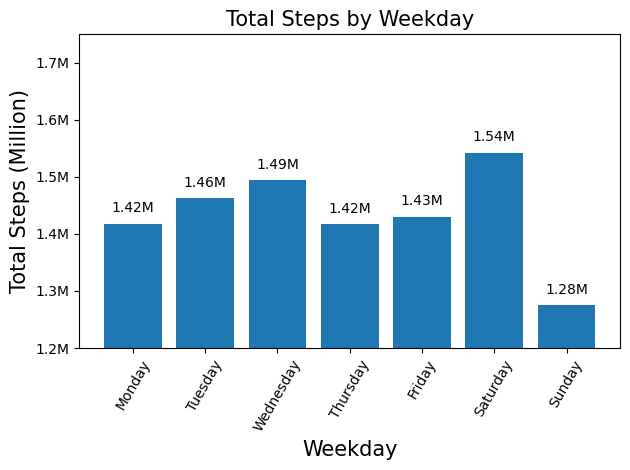

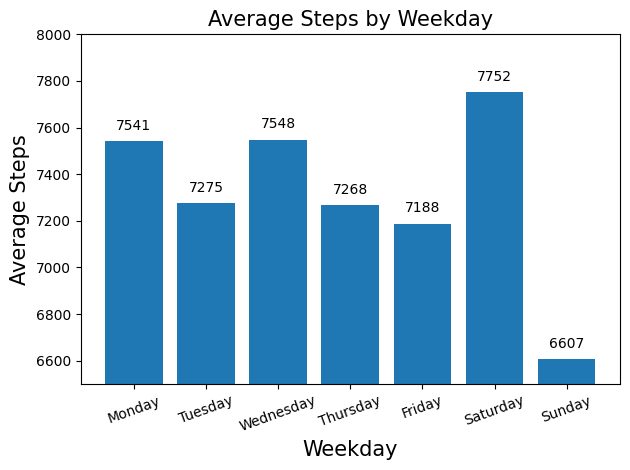

In [31]:
## Total Steps

def millions(x, pos):
    return f'{x * 1e-6:.1f}M'
sum_bar_steps = plt.bar(week_order, weekday_sum_steps)
labels = [f"{v / 1_000_000:.2f}M" for v in weekday_sum_steps]
plt.gca().yaxis.set_major_formatter(FuncFormatter(millions))
plt.bar_label(sum_bar_steps, labels=labels, padding=6)
plt.gca().set_ylim(1_200_000, 1750000)
plt.title('Total Steps by Weekday', size=15)
plt.xlabel('Weekday', size=15)
plt.ylabel('Total Steps (Million)', size=15)
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

mean_step_bar = plt.bar(week_order, weekday_average_steps)
plt.bar_label(mean_step_bar, padding=6)
plt.gca().set_ylim(6500,8000)
plt.title('Average Steps by Weekday', size=15)
plt.xlabel('Weekday', size=15)
plt.ylabel('Average Steps', size=15)
plt.xticks(rotation=20)
plt.ticklabel_format(style='plain',axis='y')
plt.tight_layout()
plt.show()

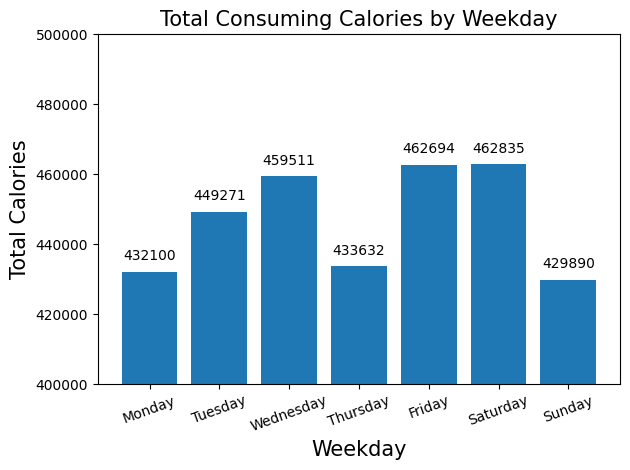

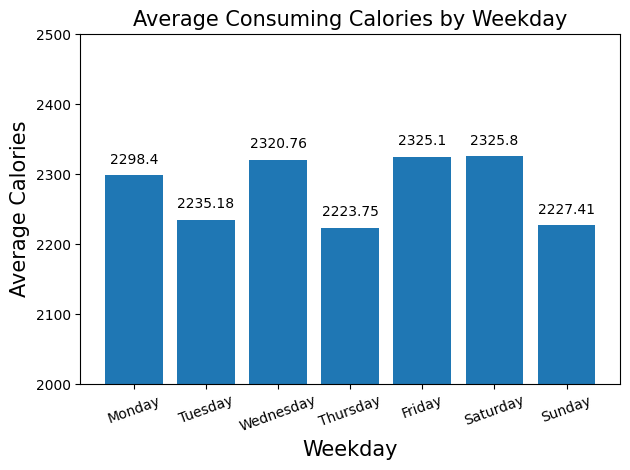

In [33]:
## Calories
sum_bar_calories = plt.bar(week_order, weekday_sum_calories)
plt.bar_label(sum_bar_calories, padding=6)
plt.gca().set_ylim(400000,500000)
plt.title('Total Consuming Calories by Weekday', size=15)
plt.xlabel('Weekday', size=15)
plt.ylabel('Total Calories', size=15)
plt.xticks(rotation=20)
plt.ticklabel_format(style='plain',axis='y')
plt.tight_layout()
plt.show()


mean_calory_bar = plt.bar(week_order, weekday_average_calories)
plt.bar_label(mean_calory_bar, padding=6)
plt.gca().set_ylim(2000,2500)
plt.title('Average Consuming Calories by Weekday', size=15)
plt.xlabel('Weekday', size=15)
plt.ylabel('Average Calories', size=15)
plt.xticks(rotation=20)
plt.ticklabel_format(style='plain',axis='y')
plt.tight_layout()
plt.show()


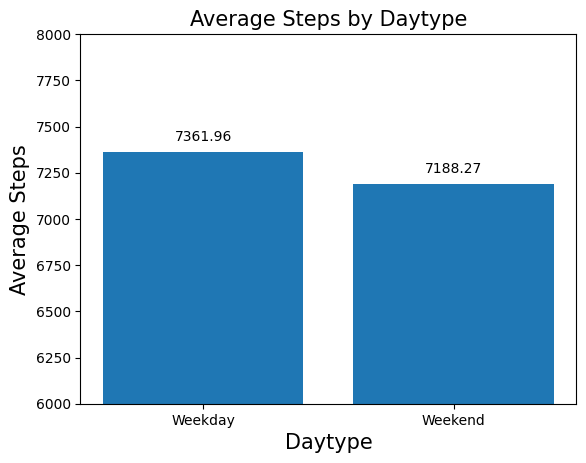

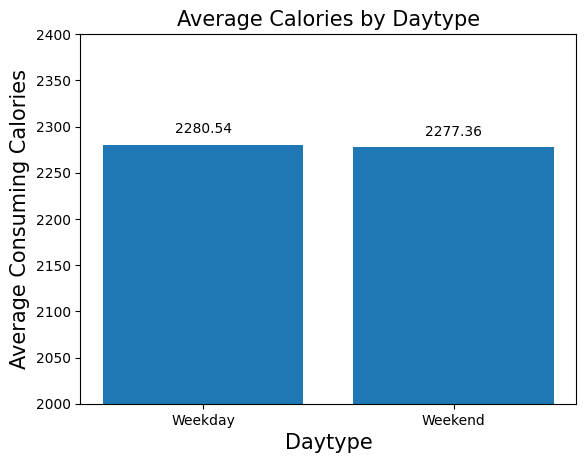

In [34]:
## Daytype
##needed data to make chaets (Since the number of weekdays in the dataset is clearly higher, I excluded total values and focused on averages for a fair comparison.)
daytype_mean_steps = [_ for _ in mean_by_daytype['TotalSteps']]
daytype_mean_calirues = [_ for _ in mean_by_daytype['Calories']]
day_type = ['Weekday','Weekend']

dtype_bar_steps = plt.bar(day_type, daytype_mean_steps)
plt.bar_label(dtype_bar_steps, padding=6)
plt.gca().set_ylim(6000,8000)
plt.title('Average Steps by Daytype', size=15)
plt.xlabel('Daytype',size=15)
plt.ylabel('Average Steps', size=15)
plt.show()

dtype_bar_calories = plt.bar(day_type, daytype_mean_calirues)
plt.bar_label(dtype_bar_calories, padding=6)
plt.gca().set_ylim(2000,2400)
plt.title('Average Calories by Daytype', size=15)
plt.xlabel('Daytype',size=15)
plt.ylabel('Average Consuming Calories', size=15)
plt.show()


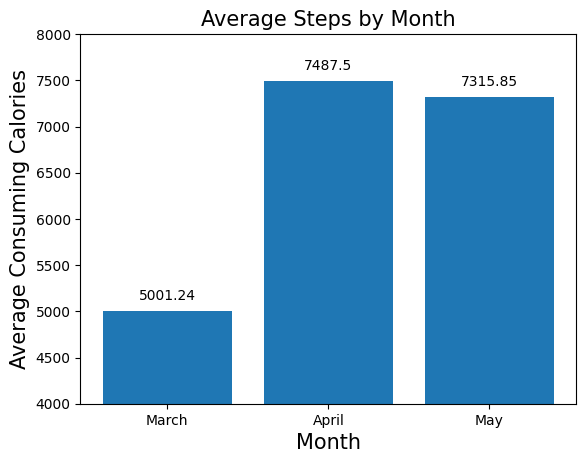

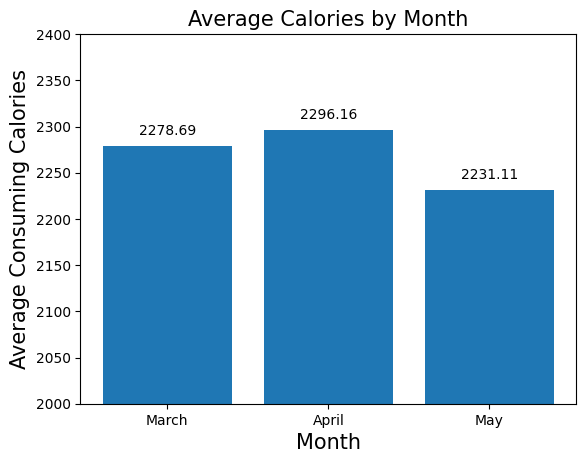

In [35]:
## Month
##needed data to make chaets(Since the number of weekdays in the dataset is clearly higher, I excluded total values and focused on averages for a fair comparison.)
month_mean_steps = [_ for _ in mean_by_month['Mean Steps']]
month_mean_calories = [_ for _ in mean_by_month['Mean Calories']]
month = ['March','April','May']

m_bar_steps = plt.bar(month, month_mean_steps)
plt.bar_label(m_bar_steps, padding=6)
plt.gca().set_ylim(4000,8000)
plt.title('Average Steps by Month', size=15)
plt.xlabel('Month',size=15)
plt.ylabel('Average Consuming Calories', size=15)
plt.show()

m_bar_calories = plt.bar(month, month_mean_calories)
plt.bar_label(m_bar_calories, padding=6)
plt.gca().set_ylim(2000,2400)
plt.title('Average Calories by Month', size=15)
plt.xlabel('Month',size=15)
plt.ylabel('Average Consuming Calories', size=15)
plt.show()

In [36]:
## Comparison between Active and Non-active users!
## needed data to make charts
active_user_min = [x for x in active_users['VeryActiveMinutes']]
active_user_steps = [x for x in active_users['TotalSteps']]
active_user_calories = [x for x in active_users['Calories']]
non_active_user_min = [x for x in non_active_users['VeryActiveMinutes']]
non_active_user_steps = [x for x in non_active_users['TotalSteps']]
non_active_user_calories = [x for x in non_active_users['Calories']]

user_calories_median = df_daily['Calories'].median()
user_calories_mean = df_daily['Calories'].mean()


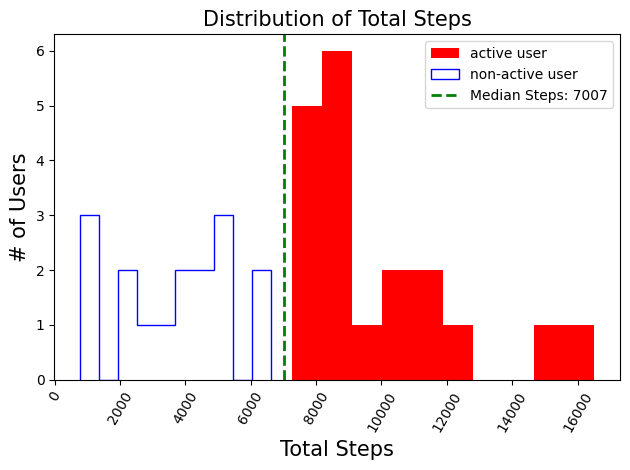

In [37]:
### Distribution of Total Steps
plt.hist(active_user_steps, color='red', label='active user')
plt.hist(non_active_user_steps, color='blue', label='non-active user', histtype='step')
plt.title('Distribution of Total Steps', size=15)
plt.xlabel('Total Steps', size=15)
plt.ylabel('# of Users', size=15)
plt.axvline(user_median_steps, color='green', linestyle='--', linewidth=2, label=f'Median Steps: {int(user_median_steps)}') #to show median steps
plt.legend()
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

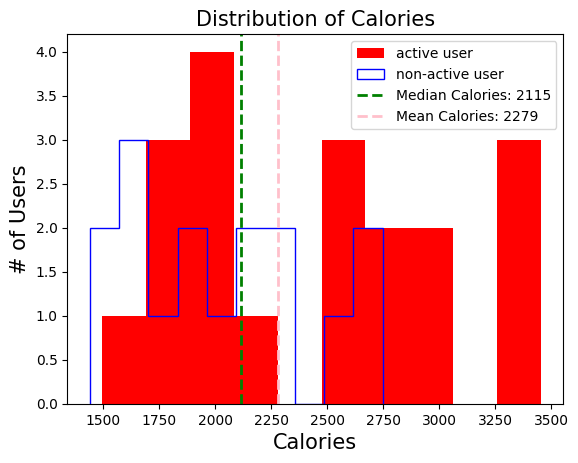

In [38]:
### Distribution of Calories
plt.hist(active_user_calories, color='red', label='active user')
plt.hist(non_active_user_calories, color='blue', label='non-active user', histtype='step')
plt.title('Distribution of Calories', size=15)
plt.xlabel('Calories', size=15)
plt.ylabel('# of Users', size=15)
plt.axvline(user_calories_median, color='green', linestyle='--', linewidth=2, label=f'Median Calories: {int(user_calories_median)}') #to show median
plt.axvline(user_calories_mean, color='pink', linestyle='--', linewidth=2, label=f'Mean Calories: {int(user_calories_mean)}') #to show mean
plt.legend()
plt.show()

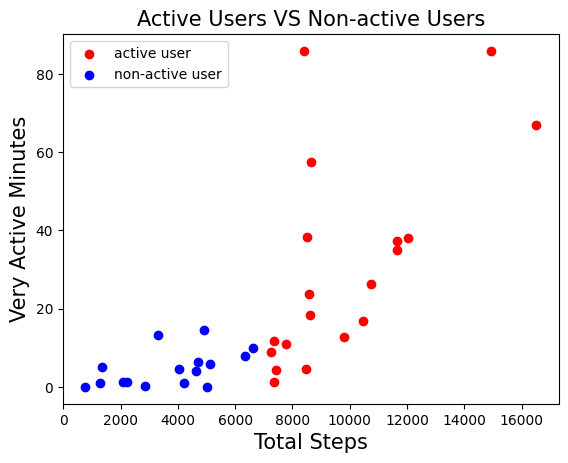

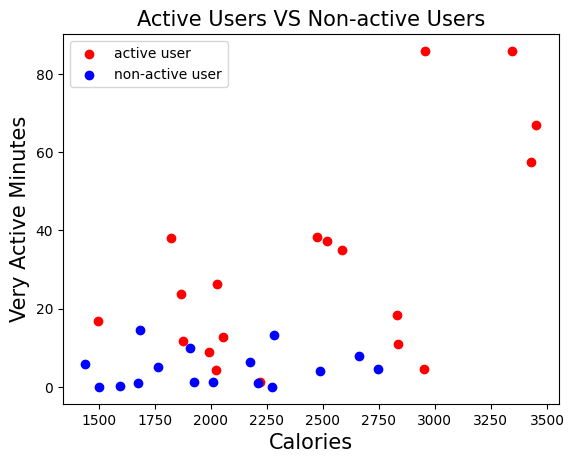

In [39]:
## Comparison of VeryActiveMinutes

#### total steps and very active minutes
plt.scatter( x = active_user_steps, y = active_user_min, color = 'red', label = 'active user')
plt.scatter( x = non_active_user_steps, y = non_active_user_min, color = 'blue', label = 'non-active user')
plt.title('Active Users VS Non-active Users', size=15)
plt.xlabel('Total Steps', size=15)
plt.ylabel('Very Active Minutes', size=15)
plt.legend()
plt.show()

#### calories and vary active minutes
plt.scatter( x = active_user_calories, y = active_user_min, color = 'red', label = 'active user')
plt.scatter( x = non_active_user_calories, y = non_active_user_min, color = 'blue', label = 'non-active user')
plt.title('Active Users VS Non-active Users', size=15)
plt.xlabel('Calories', size=15)
plt.ylabel('Very Active Minutes', size=15)
plt.legend()
plt.show()


## 4-4. summarize overall
correlation result!

|                       | TotalSteps | VeryActiveDistance | VeryActiveMinutes | Calories | CalculatedTotalDistance |
|-----------------------|------------|--------------------|-------------------|----------|------------------------|
| **TotalSteps**        | 1.000      | 0.737              | 0.675             | 0.580    | 0.976                  |
| **VeryActiveDistance**| 0.737      | 1.000              | 0.834             | 0.475    | 0.788                  |
| **VeryActiveMinutes** | 0.675      | 0.834              | 1.000             | 0.590    | 0.700                  |
| **Calories**          | 0.580      | 0.475              | 0.590             | 1.000    | 0.637                  |
| **CalculatedTotalDistance** | 0.976 | 0.788              | 0.700             | 0.637    | 1.000                  |

|                       | TrackerDistance | VeryActiveMinutes | FairlyActiveMinutes | LightlyActiveMinutes | SedentaryMinutes |
|-----------------------|-----------------|-------------------|---------------------|---------------------|------------------|
| **TrackerDistance**    | 1.000           | 0.689             | 0.339               | 0.541               | -0.313           |
| **VeryActiveMinutes**  | 0.689           | 1.000             | 0.234               | 0.099               | -0.182           |
| **FairlyActiveMinutes**| 0.339           | 0.234             | 1.000               | 0.115               | -0.198           |
| **LightlyActiveMinutes**| 0.541          | 0.099             | 0.115               | 1.000               | -0.470           |
| **SedentaryMinutes**   | -0.313          | -0.182            | -0.198              | -0.470              | 1.000            |

### Analysis By Weekday
Sunday shows the lowest total steps, approximately 1.28 million, while Saturday has the highest, reaching around 1.54 million. From Monday to Friday, the total steps are relatively stable, averaging around 1.4 million. This trend is consistent when looking at the average steps per weekday.

However, the trend in total calories burned differs. Monday, Wednesday, and Sunday all show similar calorie consumption, around 430,000, while the other weekdays range between 440,000 and 460,000. Despite Sunday recording the fewest steps, calorie consumption remains high, suggesting that users are engaging in other forms of activity beyond walking.

Additionally, when analyzing activity types, Sunday records the highest sedentary time and the lowest very active minutes, supporting the idea that users are less physically active but still burning calories, possibly through different kinds of activities or due to body metabolism.

### Analysis By Weektype
Users tend to walk more on weekdays than on weekends, primarily because Sunday significantly lowers the weekend average. However, the average calories burned are almost the same: approximately 2280 on weekdays and 2277 on weekends.

This suggests that even though users walk less on weekends, their calorie consumption remains steady, likely because of alternative physical activities or the body's baseline metabolic rate.

### Monthly Trends
March shows the lowest average steps, around 5000, whereas April and May average over 7000 steps, with a gap of approximately 2000 steps. However, the average calories burned remain stable across the three months, around 2200.

Interestingly, in March, users spent an average of 1162 minutes sedentary and only 7 minutes in very active activities, compared to around 900 sedentary minutes and 20 very active minutes in April and May.
This indicates that although users were less physically active in March, they maintained a similar calorie consumption level. This suggests either alternative activities not captured as steps or individual metabolic differences.

### Active VS Non-active Users

We classified users as active if their average steps were 7007 or higher, and non-active if lower, based on the overall median of total steps.

Among active users, some recorded over 14,000 steps per day, showing a wider variance. In contrast, non-active users' step counts were more evenly distributed.

Regarding calorie consumption, there is little difference in distribution between active and non-active users. Some non-active users burned more calories than the median and mean of all users, while some active users consumed fewer calories.
This suggests that calorie consumption depends not only on activity levels but also on individual characteristics such as weight, muscle mass, basal metabolic rate, and types of exercise performed.

Looking at the relationship between total steps and very active minutes:

  * Non-active users show a relatively clear positive correlation between steps and very active minutes.
  * Active users exhibit greater variability: even users with similar step counts sometimes had different very active minutes.
  * Overall, the correlation between total steps and very active minutes is approximately 0.7, indicating a moderately strong positive relationship.

This implies that users are primarily using the device to track their walking activities, but walking is not the sole contributor to their calorie expenditure.

### Additional Notes
* Activity Type by Weekday and Month:
Sunday and March show higher sedentary times and lower very active minutes compared to other periods, suggesting less intense physical activity.

* Rate of Active Dates:
The active date rate is about 63%, meaning users were not active every day during the recorded period.
This highlights that not all users recorded activities daily, which should be considered when interpreting aggregated data.



### Conclusion
By weekday, days except for Sunday are same trends regarding to total steps. However, the level of consuming calories are almost similar, so it indicates that users are doing additional activiy, not walking.

By weektype, weekday is more active than weekend only respect to total steps because Sunday is the lowest steps, while their consumig calories are almost same because users consume it even more not by walking.

By month, March have a different trend with April and May regarding total steps, while the trending on calories are almost same, so it implys that users did additional activity on March.

We also compared between active and non-active users. Obviously, active users walk more steps than non-active users, but the distribution of consuming calories depends on the users. Of course, non-active users tend to be left side of the graph, and active ones tend to be right of one, but some non-active users consume calories more than the mean and median of it. About the relationship between total steps and very active miniutes, non-active users share almost same trends looking like positive correlation. On the other hand, that of active users are more variable. Overall, the correlation between total steps and very active miniutes are positive correlation, so it indicates users are using this device for recording walking steps.

